# 라이브러리 호출

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset,DataLoader

# CPU 혹은 GPU 장치 확인

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# fashion_mnist 데이터셋 내려받기

In [3]:
train_dataset = torchvision.datasets.FashionMNIST("./data",download=True,transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("./data",download=True,train=False,transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.2MB/s]


# fashion_mnist 데이터를 데이터로더에 전달


In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=100)

In [6]:
# (image_tensor,label)
  # label -> 0~9
  # image tensor -> shape(1,28,28) : grayscale image -> 1 channel, 28x28pixels
print(train_dataset[0])

In [11]:
# select image_tensor (drop label)
print(train_dataset[0][0])

In [12]:
# 0th channel (grayscale only have one channel)
# : : -> all rows & cols
print(train_dataset[0][0][0,:,:])

# 분류에 사용될 클래스 정의

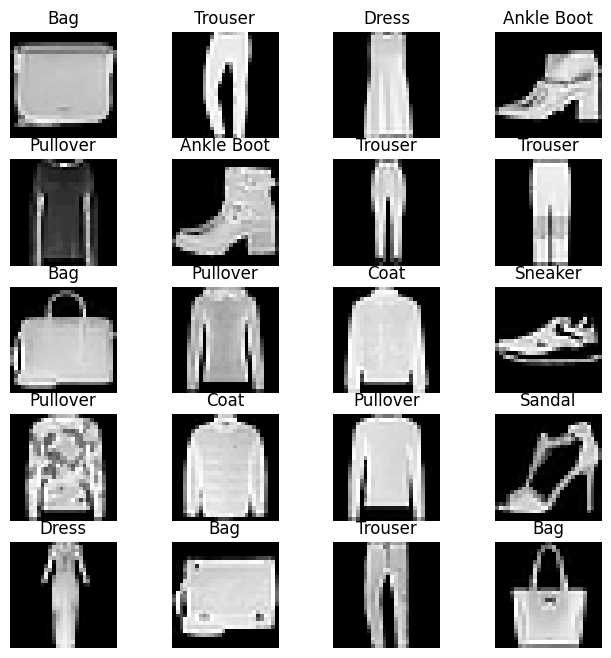

In [13]:
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot'}

fig = plt.figure(figsize=(8,8));
columns=4;
rows=5;
for i in range(1,columns*rows+1):
  img_xy = np.random.randint(len(train_dataset));
  # 28x28 grayscale image data
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows,columns,i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img,cmap='gray')
plt.show()

# 심층 신경망 모델 생성


In [19]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784,out_features=256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256,out_features=128)
    self.fc3=nn.Linear(in_features=128,out_features=10)
  def forward(self,input_data):
    out=input_data.view(-1,784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

# 심층 신경망에서 필요한 파라미터 정의

In [18]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


# 심층 신경먕을 이용한 모델 학습

In [20]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images,labels in train_loader:
    images,labels = images.to(device),labels.to(device)

    train = Variable(images.view(100,1,28,28)) #(batch_size, channels, height, width)
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not(count%50):
      total = 0
      correct = 0
      for images,labels in test_loader:
        images,labels = images.to(device),labels.to(device)
        labels_list.append(labels)

        test = Variable(images.view(100,1,28,28))

        outputs = model(test) # outputs : (batch_size, num_classes)
        # higest_between_classes, higest_indices = torch.max(outputs, 1)
        # [1] : highest_indices
        """
        Suppose outputs for 1 image = [0.1, 0.7, -0.3, 0.2]
        torch.max(outputs, 0) → (0.7, 1)
        The max value = 0.7, index = 1.
        Index 1 means the model predicts class 1.
        """
        predictions = torch.max(outputs,1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions==labels).sum()
        total += len(labels)
      accuracy = correct*100/total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

      if not(count%500):
        print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count,loss.data,accuracy))




Iteration: 500, Loss: 0.6111689209938049, Accuracy: 83.44999694824219%
Iteration: 1000, Loss: 0.46032240986824036, Accuracy: 84.33999633789062%
Iteration: 1500, Loss: 0.36728793382644653, Accuracy: 84.80999755859375%
Iteration: 2000, Loss: 0.3813297152519226, Accuracy: 85.07999420166016%
Iteration: 2500, Loss: 0.30106472969055176, Accuracy: 85.58999633789062%
Iteration: 3000, Loss: 0.2997231185436249, Accuracy: 86.66999816894531%


# 합상곱 네트워크 생성

In [21]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6,out_features=600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600,out_features=120)
    self.fc3 = nn.Linear(in_features=120,out_features=10)

  def forward(self,x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0),-1) #flatten
    out = self.fc1(out)
    out=self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

# 합상곱 네트워크를 위한 파라미터 정의

In [22]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


# 모델 학습 및 성능 평가

In [23]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.4703223705291748, Accuracy: 87.98999786376953%
Iteration: 1000, Loss: 0.30557647347450256, Accuracy: 88.18000030517578%
Iteration: 1500, Loss: 0.3030589818954468, Accuracy: 86.77999877929688%
Iteration: 2000, Loss: 0.249607652425766, Accuracy: 88.33999633789062%
Iteration: 2500, Loss: 0.09701865911483765, Accuracy: 89.58999633789062%
Iteration: 3000, Loss: 0.16584041714668274, Accuracy: 90.30999755859375%
